In [ ]:

!pip install librosa numpy matplotlib scipy ipywidgets
from google.colab import files
import librosa
import numpy as np
import matplotlib.pyplot as plt  # ← faltaba esto
import librosa.display



📁 Seleccioná tu archivo de audio...


Saving prueba.ogg to prueba (4).ogg
✅ Cargado: prueba (4).ogg
📋 Mi Voz:


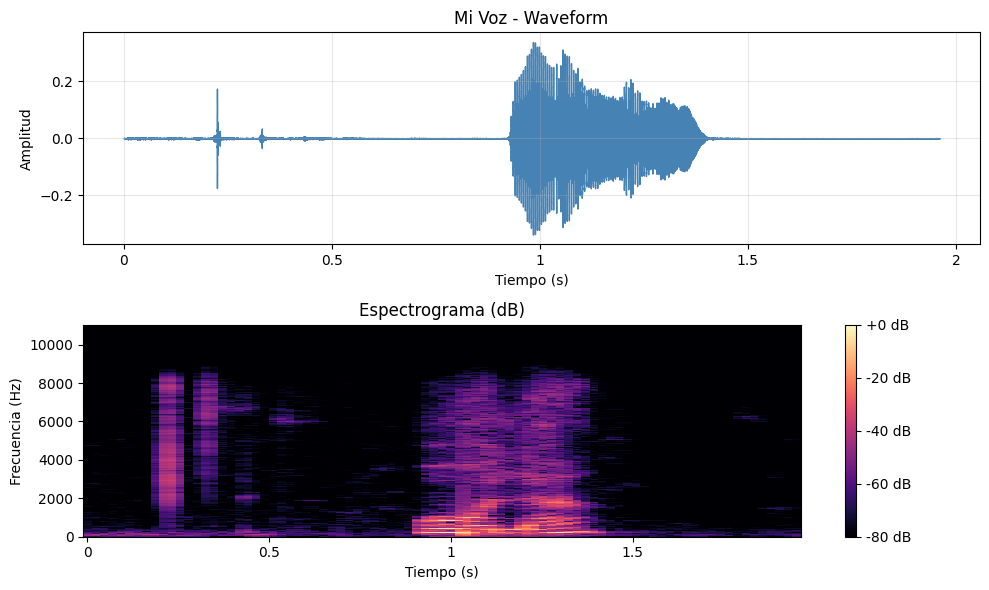

📏 Duración: 1.96 s
🔊 Amplitud: [-0.210, 0.339]
⚡ Energía RMS: 0.0444
🔄 Zero-Crossing Rate medio: 0.1338


In [ ]:


# Abre un explorador para subir archivo
print("📁 Seleccioná tu archivo de audio...")
uploaded = files.upload()

# Carga el archivo subido
nombre = list(uploaded.keys())[0]
mi_voz, sr_voz = librosa.load(nombre, sr=22050)
print(f"✅ Cargado: {nombre}")

# Diagnosticar
def diagnosticar_audio(audio, sr, titulo="Diagnóstico"):
    """Muestra waveform y espectrograma básico para evaluación visual"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

    # Waveform
    librosa.display.waveshow(audio, sr=sr, ax=ax1, color='steelblue')
    ax1.set_title(f'{titulo} - Waveform')
    ax1.set_xlabel('Tiempo (s)')
    ax1.set_ylabel('Amplitud')
    ax1.grid(True, alpha=0.3)

    # Espectrograma (STFT básica)
    D = np.abs(librosa.stft(audio))
    S_db = librosa.amplitude_to_db(D, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', ax=ax2,
                                   cmap='magma')
    ax2.set_title('Espectrograma (dB)')
    ax2.set_xlabel('Tiempo (s)')
    ax2.set_ylabel('Frecuencia (Hz)')
    plt.colorbar(img, ax=ax2, format='%+2.0f dB')

    plt.tight_layout()
    plt.show()

    # Métricas rápidas
    print(f"📏 Duración: {len(audio)/sr:.2f} s")
    print(f"🔊 Amplitud: [{audio.min():.3f}, {audio.max():.3f}]")
    print(f"⚡ Energía RMS: {np.sqrt(np.mean(audio**2)):.4f}")
    print(f"🔄 Zero-Crossing Rate medio: {librosa.feature.zero_crossing_rate(audio).mean():.4f}")

# 🔍 Diagnosticar audio de prueba
print("📋 Mi Voz:")
diagnosticar_audio(mi_voz, sr_voz, "Mi Voz")